In [1]:
from matplotlib.ticker import LinearLocator
from jax import jit, random, vmap
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import config
import jax
import sys
from functools import partial

sys.path.append("../src")

jax.config.update("jax_platform_name", "cpu")

config.update("jax_enable_x64", True)

In [2]:
from configuration.rte1d_settings import get_config
from geometry.meshxd_ds import UniformMeshXV
from modules.generator import Sample1D
from modules.solution import Constructor1D
from solver.least_square import solve
from constraints.continuous1d_oe import (
    PointwiseBoundaryConstraint1D as BC,
)
from constraints.continuous1d_oe import (
    PointwiseInteriorConstraint1D as EQ,
)

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Mp_f = rte_config.model.Mp["f"]
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["f"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
bdy_value = rte_config.model.bdy_cond
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_f = UniformMeshXV(domain=domain, strides=strides)

In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
dummy_x, dummy_v = jnp.split(jnp.array([0.0, 0.0]), 2, axis=0)
params = {}
eq_instance = rte.apply(params, dummy_x, dummy_v)
bc_instance = bc.apply(params, dummy_x, dummy_v)

In [6]:
# (2, Mp_rho*Jn_rho+Mp_g*Jn_g), (Mp_rho*Jn_rho+Mp_g*Jn_g,)
eq_instance.shape, bc_instance.shape

((1, 128), (128,))

In [7]:
def eq_fn(x, v):
    return partial(rte.apply, params)(x, v)


def bc_fn(x, v):
    return partial(bc.apply, params)(x, v)


def rhs_fn(x, v):
    q = source_fn(x, v).squeeze()
    return jnp.array([kn**2 * q])


def integrator(fn, quadratures, argnum):
    pts, ws = quadratures

    def integral_fn(*args):
        args = list(args)
        in_axes_ = [None] * len(args)
        args.insert(argnum, pts)
        in_axes_.insert(argnum, int(0))
        vmap_fns = vmap(fn, in_axes=in_axes_, out_axes=-1)(*args)
        out = jnp.dot(vmap_fns, ws).squeeze()
        return jnp.array(out)

    return integral_fn


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

# vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
#     vmap(jit(eq_fn)),
#     vmap(jit(bc_fn)),
#     vmap(jit(rhs_fn)),
# )

# vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = vmap(eq_fn), vmap(bc_fn), vmap(rhs_fn)

# time
# vmap - 9:11
# vmap+jit - 1:55
# jit+vmap - 1:49

In [8]:
sampler = Sample1D(domain=domain, collocation_sizes=collocation_sizes, mode=mode)
xv_int, xv_bcl, xv_bcr = sampler.pts_int, sampler.pts_left, sampler.pts_right

In [9]:
# Evaluate the functions
bc_left, bc_right = vmap_bc_fn(*xv_bcl), vmap_bc_fn(*xv_bcr)

In [10]:
eq_int = vmap_eq_fn(*xv_int)

In [11]:
rhs_int = vmap_rhs_fn(*xv_int)

In [12]:
print(f"Boundary: {bc_left.shape}, {bc_right.shape}, Interior: {eq_int.shape}")

Boundary: (64, 128), (64, 128), Interior: (960, 1, 128)


In [13]:
# Save the data
matrix_A = np.concatenate([bc_left, bc_right, eq_int.reshape(-1, num_unknowns)], axis=0)
vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size = bc_left.shape[0]
vector_b[:bdy_size, 0] = bdy_value["f_l"](xv_bcl[-1])
vector_b[bdy_size : 2 * bdy_size, 0] = bdy_value["f_r"](xv_bcr[-1])
vector_b[2 * bdy_size :, 0] = rhs_int.reshape(-1)
print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (1088, 128), Vector b: (1088, 1)


In [14]:
print("Matrix A 内存 %.2f MB" % (matrix_A.nbytes / 1024**2))
print("Vector b 内存 %.2f MB" % (vector_b.nbytes / 1024**2))

Matrix A 内存 1.06 MB
Vector b 内存 0.01 MB


In [15]:
vector_U = solve(matrix_A, vector_b, c=regularizer)
print(f"Vector U: {vector_U.shape}")

Vector U: (128, 1)


In [16]:
np.linalg.norm(matrix_A @ vector_U - vector_b) / np.linalg.norm(vector_b)

0.0001888589474360248

In [17]:
from numpy.linalg import cond

print(f"Condition number: {cond(matrix_A)}")

Condition number: 2.075935086902394e+17


In [18]:
matrix_A_inv = jnp.linalg.pinv(matrix_A)
matrix_A_new = matrix_A_inv @ matrix_A
vector_b_new = matrix_A_inv @ vector_b
print(f" Matrix A_new Condition number: {cond(matrix_A_new):.6e}")
vector_U_new = solve(matrix_A_new, vector_b_new)
print(
    np.linalg.norm(matrix_A_new @ vector_U_new - vector_b_new)
    / np.linalg.norm(vector_b_new),
)


 Matrix A_new Condition number: 1.112719e+09
8.990539073286507e-15


In [19]:
# data = np.load("../src/data/weights.npz")
# vector_U = data["coefficients"]

In [20]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns,
)
constructor = Constructor1D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [21]:
def approx_fn(x, v):
    return partial(constructor.apply, params)(x, v)

In [22]:
dummy_z = jnp.array([0.7, -0.5])
dummy_x, dummy_v = jnp.split(dummy_z, 2, axis=0)
print(f"f({dummy_z}) = {jit(approx_fn)(dummy_x, dummy_v)}")  # 0.15

f([ 0.7 -0.5]) = 0.30003924985118147


In [23]:
vmap_approx_fn = vmap(approx_fn)

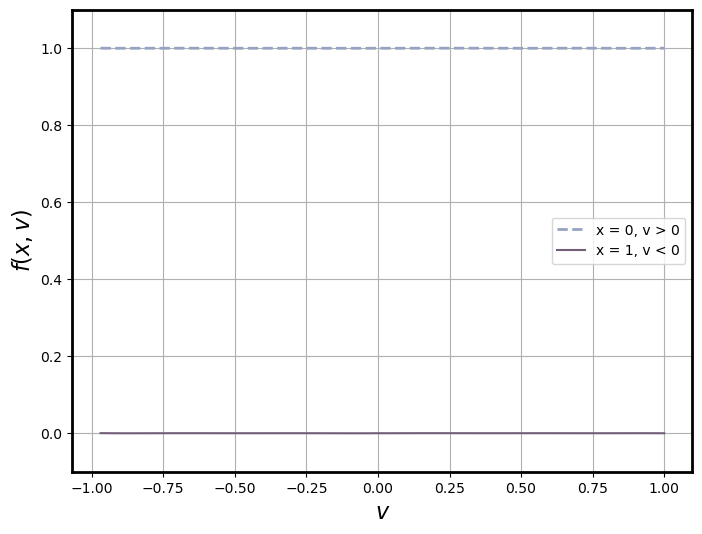

In [24]:
plt.figure(figsize=(8, 6))
ax1 = plt.subplot(1, 1, 1)
plt.plot(
    xv_bcl[1],
    vmap_approx_fn(*xv_bcl),
    "--",
    color="#94A3C0",
    markersize=10,
    linewidth=2,
    label="x = 0, v > 0",
)
plt.plot(
    xv_bcr[1],
    vmap_approx_fn(*xv_bcr),
    "-",
    color="#725E79",
    label="x = 1, v < 0",
)
plt.ylim(ymin=-0.1, ymax=1.1)
plt.xlabel(r"$v$", fontsize=16)
plt.ylabel(r"$f (x, v)$", fontsize=16)
plt.grid()
plt.legend()
# line width of four axises
ax = plt.gca()
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)
# plt.savefig("rte_approx_BC.png", dpi=300)
plt.show()
plt.close()

In [25]:
data = np.load(f"../src/data/rte1d_ex1_ref_{kn:.1e}.npz")
mesh_x, mesh_v, F = data["mesh_x"], data["mesh_v"], data["F"]
X, V = np.meshgrid(mesh_x, mesh_v)
XV = np.stack([X, V], axis=-1)
F_hat = vmap_approx_fn(*np.split(XV.reshape(-1, 2), 2, axis=1)).reshape(X.shape)
print(kn, mesh_x.shape, mesh_v.shape, F.shape, F_hat.shape)
# np.savez("../src/data/rte1d_solutions_kn.npz", X=X, V=V, F=F, F_hat=F_hat)

1.0 (511,) (254,) (254, 511) (254, 511)


In [26]:
# np.savez(
#     f"../src/data/aprfm1d_solutions_{kn:.1e}.npz", X=X, V=V, F=F, F_hat=F_hat
# )

In [27]:
jnp.linalg.norm(F_hat - F) / jnp.linalg.norm(F)

Array(0.00012026, dtype=float64)

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


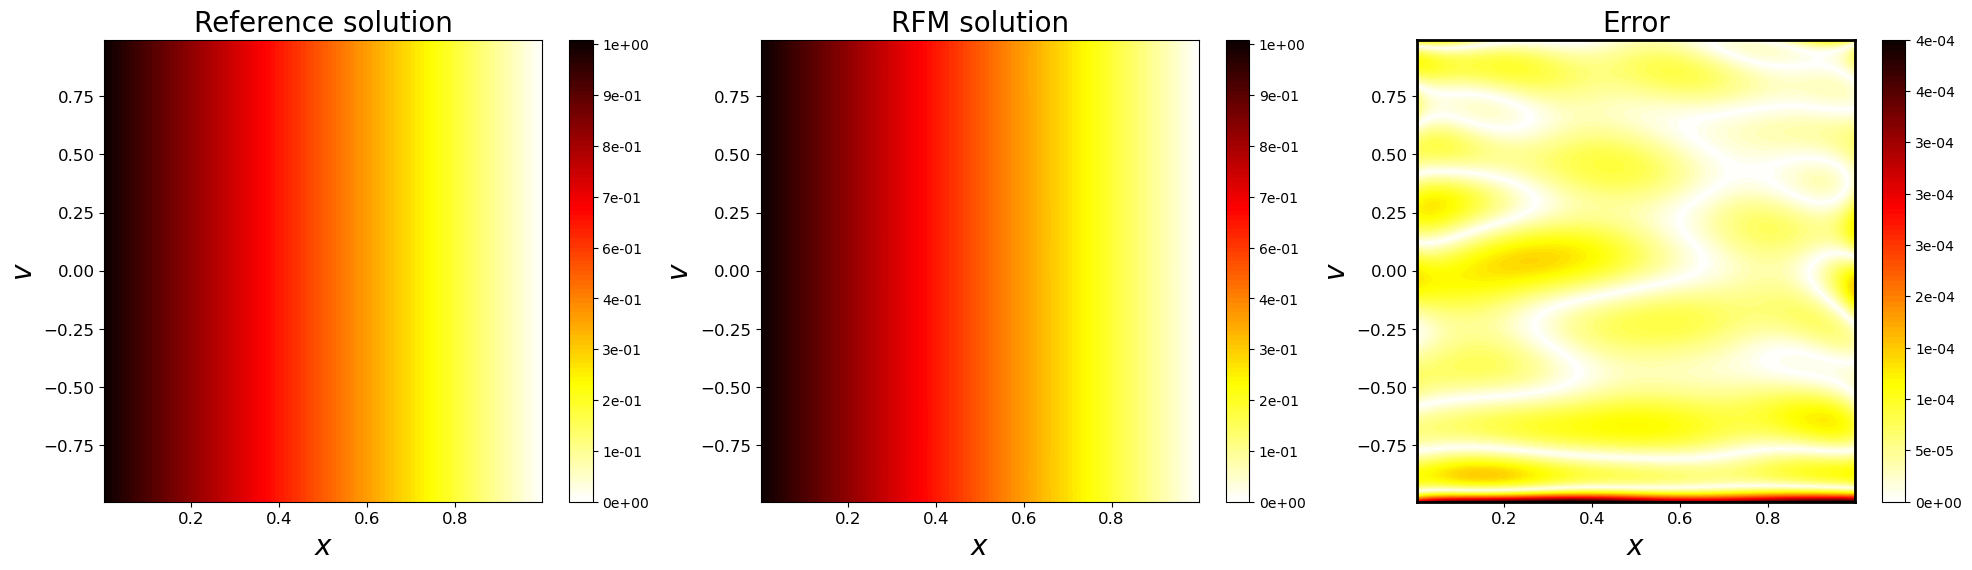

In [28]:
font_format = {"family": "Times New Roman", "size": 20}

plt.figure(figsize=(24, 6))
ax1 = plt.subplot(1, 3, 1)
plt.contourf(X, V, F, 100, cmap="hot_r")
# font size and type
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(format="%.0e")
plt.title("Reference solution", font_format)

ax2 = plt.subplot(1, 3, 2)
plt.contourf(X, V, F_hat, 100, cmap="hot_r")
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(format="%.0e")
plt.title("RFM solution", font_format)

ax3 = plt.subplot(1, 3, 3)
plt.contourf(X, V, np.abs(F - F_hat), 100, cmap="hot_r")
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(format="%.0e")
plt.title("Error", font_format)
# line width of four axises
ax = plt.gca()
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)

# plt.savefig(f"./figures/rfm1d_{kn:.1e}.png", dpi=300)
plt.show()
plt.close()

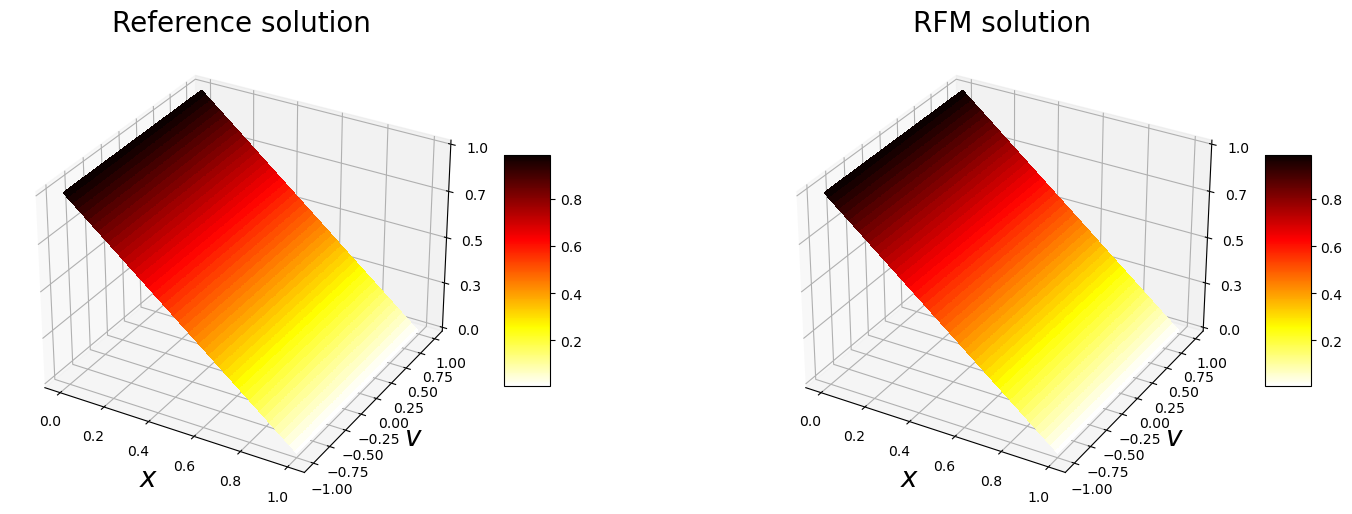

In [29]:
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
surf1 = ax1.plot_surface(X, V, F, cmap="hot_r", linewidth=0, antialiased=False)
ax1.set_xlabel(r"$x$", font_format)
ax1.set_ylabel(r"$v$", font_format)
ax1.zaxis.set_major_locator(LinearLocator(5))
ax1.zaxis.set_major_formatter("{x:.01f}")
ax1.set_title("Reference solution", font_format)
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)
fig.colorbar(surf1, shrink=0.5, aspect=5)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
surf2 = ax2.plot_surface(X, V, F_hat, cmap="hot_r", linewidth=0, antialiased=False)
ax2.set_xlabel(r"$x$", font_format)
ax2.set_ylabel(r"$v$", font_format)
ax2.set_title("RFM solution", font_format)
ax2.zaxis.set_major_locator(LinearLocator(5))
ax2.zaxis.set_major_formatter("{x:.01f}")
ax2.spines["bottom"].set_linewidth(2)
ax2.spines["left"].set_linewidth(2)
ax2.spines["right"].set_linewidth(2)
ax2.spines["top"].set_linewidth(2)
fig.colorbar(surf2, shrink=0.5, aspect=5)

plt.show()
plt.close()